# Model Training and Evaluation Report

This report replaces the single logistic-regression baseline with a four-family comparison (`dummy`, `logistic_regression`, `random_forest`, `xgboost`). Each tunable family is hyperparameter-searched and cross-validated on the **training data only**, scored by mean cross-validated **PR-AUC** — the appropriate metric under the ~6.6% fail-rate imbalance. The winner is the family with the highest CV PR-AUC, persisted to a stable `models/selected_model.joblib` artifact.

Selection never sees the test set. The held-out test split is read exactly once, after the winner is locked, to estimate generalization and to build a per-family comparison table at each family's cost-optimal threshold.

On cross-validation the winner is **random_forest** (CV PR-AUC ≈ 0.217), edging out xgboost (≈ 0.208) and logistic regression (≈ 0.182); `dummy` (≈ 0.066) marks the chance floor at the base fail rate.

## Analysis Inputs

The analysis uses the processed train/test split, the per-family hyperparameter grids in `configs/model_config.yaml`, and the cost matrix in `configs/cost_config.yaml`. Training and selection run against `processed/train.csv` only; `processed/test.csv` is loaded once for the held-out comparison. Generated artifacts — per-family pipelines, the stable `selected_model.joblib`, `reports/cv_results.json`, `reports/model_comparison.{csv,json}`, and `reports/selected_model_metrics.json` — are written under `models/` and `reports/`, keeping the evaluation tied to the exact configuration and data split summarized below.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

sys.path.insert(0, "../src")

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from yield_risk.config import load_config, load_cost_config, load_model_config
from yield_risk.evaluate import compute_metrics, format_report, save_metrics
from yield_risk.importance import extract_feature_importance, plot_top_features
from yield_risk.model import MODEL_REGISTRY, run_search, select_best
from yield_risk.thresholding import find_optimal_threshold, threshold_cost_curve

ROOT = Path("..").resolve()

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Configuration

The configuration fixes the random seed, a 20% held-out test split, five cross-validation folds, and preprocessing filters for missingness, variance, and correlation. The randomized search draws up to `search_n_iter` candidates per tunable family (capped at the grid size). The cost matrix assigns a false pass ten times the cost of a false fail, so threshold selection is evaluated against failure escapes rather than overall classification accuracy.

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")
cost_cfg = load_cost_config(ROOT / "configs" / "cost_config.yaml")
model_cfg = load_model_config(ROOT / "configs" / "model_config.yaml")

processed_dir = ROOT / "data" / "processed"
models_dir = ROOT / "models"
reports_dir = ROOT / "reports"
figures_dir = reports_dir / "figures"

config_summary = pd.DataFrame(
    [
        ("random_seed", cfg.run.random_seed),
        ("test_size", cfg.run.test_size),
        ("cv_folds", cfg.run.cv_folds),
        ("missing_threshold", cfg.run.missing_threshold),
        ("variance_threshold", cfg.run.variance_threshold),
        ("correlation_threshold", cfg.run.correlation_threshold),
        ("search_n_iter", model_cfg["search"]["n_iter"]),
        ("false_fail_cost", cost_cfg.cost_matrix.false_fail),
        ("false_pass_cost", cost_cfg.cost_matrix.false_pass),
        ("threshold_low", cost_cfg.threshold_search.low),
        ("threshold_high", cost_cfg.threshold_search.high),
        ("threshold_steps", cost_cfg.threshold_search.steps),
    ],
    columns=["setting", "value"],
)
config_summary

,setting,value
0,random_seed,42.00
1,test_size,0.20
2,cv_folds,5.00
3,missing_threshold,0.60
4,variance_threshold,0.01
5,correlation_threshold,0.95
6,search_n_iter,20.00
7,false_fail_cost,1.00
8,false_pass_cost,10.00
9,threshold_low,0.01


The configured review is conservative in two ways: each family's quality is estimated by cross-validation before any family touches the test set, and the decision threshold is judged with an explicit false-pass penalty. This matters because the class balance is highly skewed toward passing wafers, so a single point estimate on the test set would be both noisy and prone to leakage if it drove model choice.

## Train/Test Population

The processed data contain 1,253 training rows and 314 test rows across 198 sensor features. Failure prevalence is nearly identical in both splits, with a 6.62% train fail rate and a 6.69% test fail rate, so the held-out test set is representative of the rare-failure regime seen during fitting.

In [3]:
train_path = ROOT / "data" / "processed" / "train.csv"
test_path = ROOT / "data" / "processed" / "test.csv"
missing_paths = [path for path in [train_path, test_path] if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Processed train/test data are required. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sensor_cols = [column for column in train.columns if column.startswith("sensor_")]
if not sensor_cols:
    raise ValueError("No sensor_* columns found in processed training data.")

X_train = train[sensor_cols]
y_train = train["label"]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train), len(test)],
        "fail_rate": [y_train.mean(), test["label"].mean()],
        "sensor_count": [len(sensor_cols), len(sensor_cols)],
    }
)
split_summary

,split,rows,fail_rate,sensor_count
0,train,1253,0.066241,198
1,test,314,0.066879,198


The low failure rate means a model can appear stable while missing most failures. The empirical interpretation therefore centers on ROC-AUC, PR-AUC, recall, false passes, and cost-sensitive threshold behavior.

## Cross-Validation Across Families

Each family is tuned and scored on the training split with stratified five-fold cross-validation, optimizing average precision (PR-AUC). Tunable families (`logistic_regression`, `random_forest`, `xgboost`) run a randomized hyperparameter search; `dummy` is scored directly as the chance floor. For XGBoost, `scale_pos_weight` is set from the training class ratio. Estimators run single-threaded and parallelism is applied only at the search level to avoid CPU oversubscription.

`random_forest` wins with a mean CV PR-AUC of 0.217 ± 0.071, ahead of `xgboost` (0.208 ± 0.090) and `logistic_regression` (0.182 ± 0.093). The wide standard-deviation bands reflect the rare-failure regime: with so few positives per fold, fold-to-fold PR-AUC is volatile, and the top three families overlap within one standard deviation.

In [4]:
search_results = [
    run_search(
        name,
        X_train,
        y_train,
        model_cfg,
        cfg.run.cv_folds,
        cfg.run.random_seed,
    )
    for name in MODEL_REGISTRY
]

cv_summary = (
    pd.DataFrame(
        {
            "model": [r.name for r in search_results],
            "cv_pr_auc_mean": [r.cv_pr_auc_mean for r in search_results],
            "cv_pr_auc_std": [r.cv_pr_auc_std for r in search_results],
            "best_params": [r.best_params for r in search_results],
        }
    )
    .sort_values("cv_pr_auc_mean", ascending=False)
    .reset_index(drop=True)
)
cv_summary

,model,cv_pr_auc_mean,cv_pr_auc_std,best_params
0,random_forest,0.216511,0.071227,"{'classifier__n_estimators': 300, 'classifier_..."
1,xgboost,0.208186,0.090204,"{'classifier__subsample': 0.8, 'classifier__n_..."
2,logistic_regression,0.181964,0.092818,{'classifier__C': 0.001}
3,dummy,0.066003,0.001909,{}


In [5]:
winner = select_best(search_results)
winning = next(r for r in search_results if r.name == winner)

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

for result in search_results:
    joblib.dump(result.estimator, models_dir / f"{result.name}.joblib")

selected_path = models_dir / "selected_model.joblib"
joblib.dump(winning.estimator, selected_path)

cv_records = [
    {
        "model": r.name,
        "cv_pr_auc_mean": r.cv_pr_auc_mean,
        "cv_pr_auc_std": r.cv_pr_auc_std,
        "best_params": r.best_params,
        "selected": r.name == winner,
    }
    for r in search_results
]
(reports_dir / "cv_results.json").write_text(json.dumps(cv_records, indent=2))

print(f"Selected winner by CV PR-AUC: {winner}")
print(f"Best params: {winning.best_params}")
print(f"Saved {len(search_results)} per-family models and {selected_path.name} to {models_dir}")

Selected winner by CV PR-AUC: random_forest
Best params: {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 20}
Saved 4 per-family models and selected_model.joblib to C:\Users\Virgil\Code\semiconductor-yield-root-cause\models


Selection is fixed before test evaluation: the winner was chosen on cross-validated PR-AUC over the training split alone, and is persisted to the stable `selected_model.joblib`. Downstream consumers (feature importance, SHAP explanations, batch scoring) load that one path and never reference a specific family, so the choice of winner can change without any downstream edits. Cross-validation supports a modest modeling claim: the sensor set carries predictive information, but no family is strong enough for high-confidence automated disposition. Downstream explanations are useful for ranking sensors and prioritizing engineering review.

## Held-Out Comparison

Selection is fixed before test evaluation. Every family is scored on the held-out wafers at its **own** cost-optimal threshold, and the resulting test metrics are joined to the CV PR-AUC that drove selection.

On test, the selected `random_forest` reaches ROC-AUC 0.758 and PR-AUC 0.193 at a cost-optimal threshold of 0.08 (expected cost 148). Notably `xgboost` scores higher on the test set (PR-AUC 0.261, ROC-AUC 0.802, expected cost 119) despite ranking second on CV — an expected divergence discussed at the end of this report.

In [6]:
comparison_rows = []
for result in search_results:
    fam_prob = result.estimator.predict_proba(X_test)[:, 1]
    fam_opt = find_optimal_threshold(
        y_test, fam_prob, cost_cfg.cost_matrix, cost_cfg.threshold_search
    )
    fam_metrics = compute_metrics(y_test, fam_prob, threshold=fam_opt.threshold)
    comparison_rows.append(
        {
            "model": result.name,
            "cv_pr_auc_mean": result.cv_pr_auc_mean,
            "test_pr_auc": fam_metrics.pr_auc,
            "test_roc_auc": fam_metrics.roc_auc,
            "test_recall": fam_metrics.recall,
            "test_precision": fam_metrics.precision,
            "opt_threshold": fam_opt.threshold,
            "expected_cost": fam_opt.expected_cost,
            "selected": result.name == winner,
        }
    )

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(reports_dir / "model_comparison.csv", index=False)
(reports_dir / "model_comparison.json").write_text(json.dumps(comparison_rows, indent=2))
comparison

,model,cv_pr_auc_mean,test_pr_auc,test_roc_auc,test_recall,test_precision,opt_threshold,expected_cost,selected
0,dummy,0.066003,0.065962,0.489680,0.047619,0.047619,0.01,220.0,False
1,logistic_regression,0.181964,0.209589,0.669267,0.571429,0.130435,0.47,170.0,False
2,random_forest,0.216511,0.193402,0.758411,0.571429,0.171429,0.08,148.0,True
3,xgboost,0.208186,0.261061,0.801560,0.666667,0.222222,0.03,119.0,False


In [7]:
pipeline = winning.estimator
y_prob = pipeline.predict_proba(X_test)[:, 1]
opt = find_optimal_threshold(
    y_test, y_prob, cost_cfg.cost_matrix, cost_cfg.threshold_search
)
metrics = compute_metrics(y_test, y_prob, threshold=opt.threshold)
save_metrics(metrics, reports_dir / "selected_model_metrics.json")

print(format_report(metrics, winner))
print(
    f"\nCost-optimal threshold: {opt.threshold:.3f}; "
    f"expected cost: {opt.expected_cost:.1f}"
)

cm = metrics.confusion_matrix
confusion_df = pd.DataFrame(
    cm,
    index=["Actual pass", "Actual fail"],
    columns=["Predicted pass", "Predicted fail"],
)
# confusion_matrix layout is [[TN, FP], [FN, TP]]
false_pass = cm[1][0]  # failing wafers predicted pass (escapes)
false_fail = cm[0][1]  # passing wafers predicted fail (over-review)
print(f"\nFalse passes (failure escapes): {false_pass}")
print(f"False fails (unnecessary review): {false_fail}")
confusion_df

=== random_forest Evaluation ===
ROC AUC:    0.758
PR AUC:     0.193
Precision:  0.171
Recall:     0.571
F1 Score:   0.264

Confusion Matrix:
              Pred Pass  Pred Fail
Actual Pass        235         58
Actual Fail          9         12

Cost-optimal threshold: 0.080; expected cost: 148.0

False passes (failure escapes): 9
False fails (unnecessary review): 58


,Predicted pass,Predicted fail
Actual pass,235,58
Actual fail,9,12


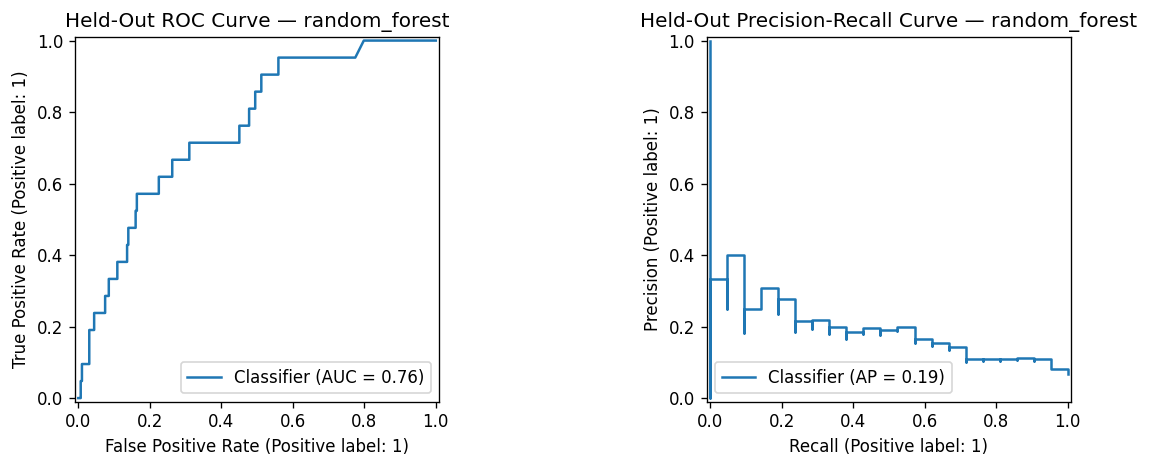

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title(f"Held-Out ROC Curve — {winner}")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f"Held-Out Precision-Recall Curve — {winner}")
plt.tight_layout()

At its cost-optimal threshold the selected random forest catches 12 of 21 failing wafers and leaves 9 failure escapes, at the cost of 58 unnecessary-review false fails. Because the configured false-pass cost is ten times the false-fail cost, the threshold analysis below — not the default 0.5 operating point — is the relevant view of the model as a decision-support component.

## Cost-Sensitive Threshold Behavior

The cost curve evaluates the selected model's probability scores under the configured false-pass and false-fail penalties. The minimum expected cost occurs at a threshold of 0.08 — far below the default 0.5 — which shifts the model toward catching more failures at the expense of more false-fail review load. The printed comparison shows the expected-cost improvement over the default operating point.

Default-threshold (0.5) expected cost: 210.0
Cost-optimal threshold 0.080 expected cost: 148.0


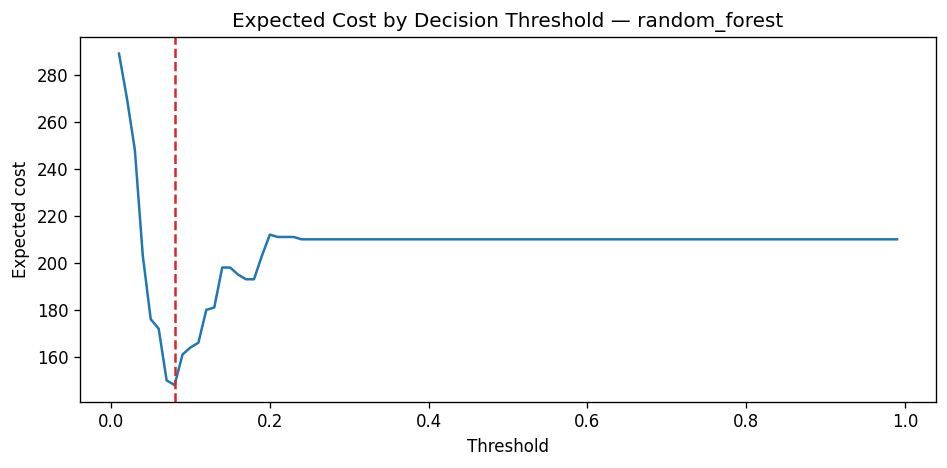

In [9]:
cost_curve = threshold_cost_curve(
    y_test, y_prob, cost_cfg.cost_matrix, cost_cfg.threshold_search
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_curve["threshold"], cost_curve["expected_cost"])
ax.axvline(opt.threshold, color="tab:red", linestyle="--")
ax.set_title(f"Expected Cost by Decision Threshold — {winner}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Expected cost")
plt.tight_layout()

default_metrics = compute_metrics(y_test, y_prob, threshold=0.5)
default_cm = default_metrics.confusion_matrix
default_cost = (
    default_cm[1][0] * cost_cfg.cost_matrix.false_pass
    + default_cm[0][1] * cost_cfg.cost_matrix.false_fail
)

print(f"Default-threshold (0.5) expected cost: {default_cost:.1f}")
print(
    f"Cost-optimal threshold {opt.threshold:.3f} expected cost: "
    f"{opt.expected_cost:.1f}"
)

Lowering the threshold to 0.08 trades unnecessary review load for fewer failure escapes, and reduces the configured expected cost relative to the default 0.5 operating point. Empirically the selected model is more useful as a high-recall screening aid than as a balanced classifier — which is exactly what the cost matrix is designed to reward.

## Feature Importance

`extract_feature_importance` reads importance from the winning pipeline regardless of family: native `feature_importances_` for tree models, signed coefficients for linear models, both normalized to a uniform `feature` / `importance` / `abs_importance` schema. Because the winner is `random_forest`, the values are non-negative impurity importances.

The leading sensors are `sensor_059`, `sensor_033`, `sensor_205`, `sensor_510`, and `sensor_031`. These identify where the model concentrates its split signal and give engineering teams a focused sensor list for follow-up. The SHAP analysis in notebook 05 checks whether the same sensors dominate attribution from a different method.

Saved feature importance to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports\feature_importance.csv


,feature,importance,abs_importance
0,sensor_059,0.023967,0.023967
1,sensor_033,0.021508,0.021508
2,sensor_205,0.016206,0.016206
3,sensor_510,0.015317,0.015317
4,sensor_031,0.015124,0.015124
5,sensor_519,0.014558,0.014558
6,sensor_129,0.011947,0.011947
7,sensor_064,0.011335,0.011335
8,sensor_200,0.010120,0.010120
9,sensor_065,0.009953,0.009953


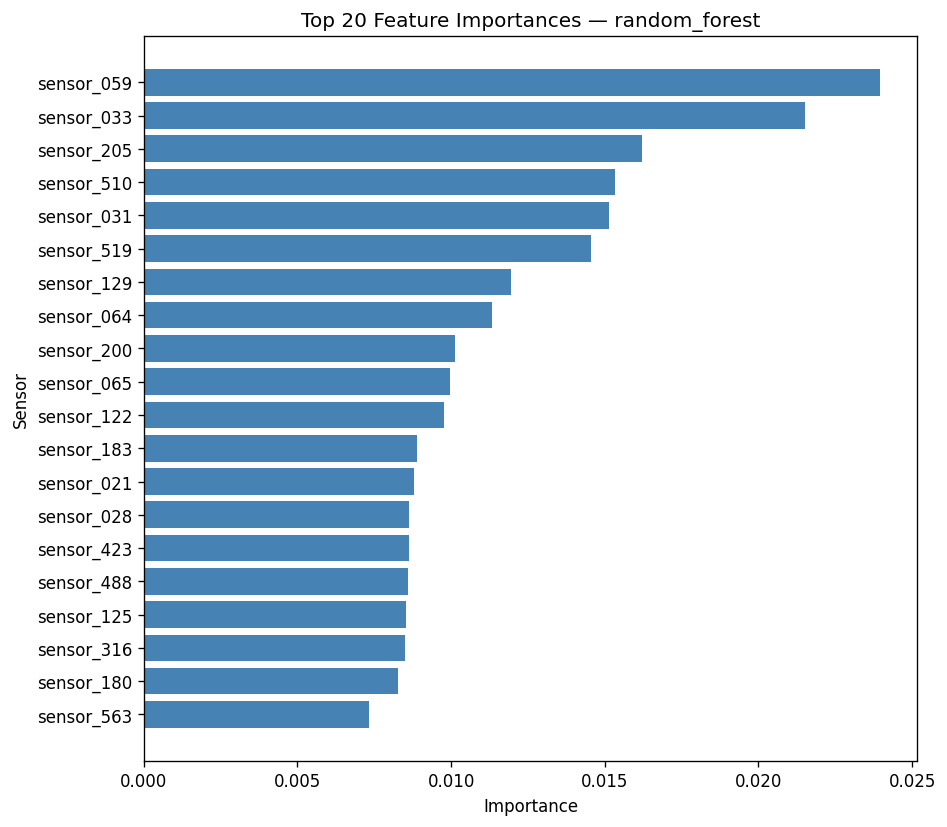

In [10]:
importance_df = extract_feature_importance(pipeline, sensor_cols)

importance_path = reports_dir / "feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

figures_dir.mkdir(parents=True, exist_ok=True)
plot_top_features(
    importance_df,
    top_n=20,
    output_path=figures_dir / "feature_importance.png",
    value_column="importance",
)

top_n = 20
top_features = importance_df.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_features["feature"], top_features["importance"], color="steelblue")
ax.set_title(f"Top {top_n} Feature Importances — {winner}")
ax.set_xlabel("Importance")
ax.set_ylabel("Sensor")
plt.tight_layout()

print(f"Saved feature importance to {importance_path}")
importance_df.head(10)

## CV vs Test Ranking

On the test set, `xgboost` outscores the selected `random_forest` (test PR-AUC 0.261 vs 0.193, ROC-AUC 0.802 vs 0.758, expected cost 119 vs 148). This follows directly from the selection protocol: the winner is chosen on cross-validation alone, and the test set is scored exactly once afterward. Letting the test ranking override the CV choice would leak the test set into selection and inflate the generalization estimate.

The divergence is small and plausible given only 21 positives in the test split and overlapping CV standard-deviation bands. The random forest remains the selected artifact under the pre-test protocol, and the XGBoost result is reported as held-out sensitivity evidence. If XGBoost's edge persisted across additional splits or a larger positive sample, the next step would be to revisit the CV protocol with more folds or repeated CV.

## Modeling Assessment

The four-family comparison shows real but limited predictive signal. The selected random forest separates failures better than chance on the held-out set (ROC-AUC 0.758), while PR-AUC stays low and recall depends heavily on the cost-tuned threshold. The cost-sensitive operating point improves the configured business objective by reducing failure escapes, so the selected model is useful for prioritizing engineering review rather than serving as a fully automated release gate. Notebook 05 takes the persisted `selected_model.joblib` forward into SHAP-based root-cause analysis.